# Full Dataset Multilabel Baseline

This notebook is the full-data training version of `model_fast.ipynb`.

It trains on the manifests produced by `full_dataset_preprocess.ipynb` and improves balance in two ways:

- offline minority clip augmentation from the preprocessing notebook
- online weighted sampling plus class-weighted loss during training

Validation uses only original clips, never augmented variants, and split membership is controlled by `source_video_id` to avoid leakage.


In [20]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
from torch.cuda.amp import GradScaler
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

warnings.filterwarnings("ignore", category=UserWarning)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def normalize_video_id(value):
    text = str(value).strip()
    if text.endswith(".0"):
        integer_candidate = text[:-2]
        if integer_candidate.isdigit():
            text = integer_candidate
    return text


DATA_ROOT = Path(r"E:\m-hvc\datasets\data-from-juniors")
# DATA_ROOT = Path(r"D:\hvc\datasets")

FRAMES_ROOT = DATA_ROOT / "full_dataset_frames"
# FRAMES_ROOT = DATA_ROOT / "frames"

MANIFEST_PATH = DATA_ROOT / "full_dataset_augmented_manifest.csv"
BASE_MANIFEST_PATH = DATA_ROOT / "full_dataset_base_manifest.csv"

CHECKPOINT_DIR = Path.cwd() / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_full_dataset_model.pt"
CHECKPOINT_PATH_EMA = CHECKPOINT_DIR / "best_full_dataset_model_ema.pt"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / "last_full_dataset_model.pt"

MODEL_TYPE = "video_transformer_v2"
PRIMARY_METRIC = "macro_f1"
SECONDARY_METRIC = "macro_ap"
DIAGNOSTIC_METRIC = "micro_f1"

CFG = {
    "seed": 42,
    "image_size": 224,
    "num_frames": 12,
    "batch_size": 16,
    "num_workers": 0,
    "epochs": 16,
    "freeze_epochs": 1,
    "warmup_ratio": 0.08,
    "val_size": 0.20,
    "val_tune_size_within_val": 0.50,
    "head_lr": 5e-4,
    "backbone_lr": 5e-5,
    "weight_decay": 2e-2,
    "grad_clip": 1.0,
    "patience": 6,
    "max_pos_weight": 20.0,
    "sampler_weight_cap": 6.0,
    "use_weighted_sampler": True,
    "ema_decay": 0.9995,
    "accum_steps": 2,
    "backbone": "efficientnet_v2_s",
    "embed_dim": 640,
    "temporal_layers": 4,
    "temporal_heads": 8,
    "ffn_dim": 1536,
    "dropout": 0.2,
    "threshold_metric": "f1",
    "threshold_min": 0.10,
    "threshold_max": 0.90,
    "threshold_steps": 33,
}

set_seed(CFG["seed"])
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print("device:", DEVICE)
print("manifest:", MANIFEST_PATH)
print("checkpoint dir:", CHECKPOINT_DIR)
print("best checkpoint:", CHECKPOINT_PATH)
print(
    "metric policy:",
    f"primary={PRIMARY_METRIC}, secondary={SECONDARY_METRIC}, diagnostic={DIAGNOSTIC_METRIC}",
)


device: cuda
manifest: E:\m-hvc\datasets\data-from-juniors\full_dataset_augmented_manifest.csv
checkpoint dir: E:\m-hvc\multimodal-hvc\checkpoints
best checkpoint: E:\m-hvc\multimodal-hvc\checkpoints\best_full_dataset_model.pt
metric policy: primary=macro_f1, secondary=macro_ap, diagnostic=micro_f1


In [21]:
manifest_df = pd.read_csv(MANIFEST_PATH)
base_manifest_df = pd.read_csv(BASE_MANIFEST_PATH)

manifest_df["source_video_id"] = manifest_df["source_video_id"].map(normalize_video_id)
manifest_df["video_key"] = manifest_df["video_key"].map(lambda value: str(value))
manifest_df["frame_dir"] = manifest_df["frame_dir"].map(lambda value: str(value))
manifest_df["is_augmented"] = manifest_df["is_augmented"].fillna(0).astype(int)

metadata_columns = {
    "video_key",
    "source_video_id",
    "video_path",
    "frame_dir",
    "is_augmented",
    "aug_index",
    "frame_count_extracted",
    "fps",
    "duration_sec",
    "width",
    "height",
}
label_columns = [column for column in manifest_df.columns if column not in metadata_columns]

manifest_df[label_columns] = manifest_df[label_columns].fillna(0).astype(int)
base_manifest_df["source_video_id"] = base_manifest_df["source_video_id"].map(normalize_video_id)
base_manifest_df[label_columns] = base_manifest_df[label_columns].fillna(0).astype(int)

original_df = manifest_df[manifest_df["is_augmented"] == 0].copy().reset_index(drop=True)
augmented_only_df = manifest_df[manifest_df["is_augmented"] == 1].copy().reset_index(drop=True)

print(f"original clips: {len(original_df):,}")
print(f"augmented clips: {len(augmented_only_df):,}")
print(f"total trainable clips in manifest: {len(manifest_df):,}")

label_summary = pd.DataFrame(
    {
        "original_positives": original_df[label_columns].sum().astype(int),
        "augmented_manifest_positives": manifest_df[label_columns].sum().astype(int),
    }
).sort_values("original_positives", ascending=False)

display(label_summary)
original_df.head()


original clips: 5,118
augmented clips: 1,566
total trainable clips in manifest: 6,684


,original_positives,augmented_manifest_positives
humour,4396,5278
sensitive,700,971
anger,373,448
derogatory__lang,351,459
generic,318,424
positive,190,412
emotional,164,334
threat,149,340
political_hate,131,320
gender_hate,109,331


,video_key,source_video_id,video_path,frame_dir,is_augmented,aug_index,frame_count_extracted,fps,duration_sec,width,...,political_hate,religion_hate,informative,ethinity_hate,anger,emotional,social_hate,controversial,indv_hate,gender_hate
0,2,2,E:\m-hvc\datasets\data-from-juniors\videos\2.mp4,E:\m-hvc\datasets\data-from-juniors\full_datas...,0,0,16,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1,9,9,E:\m-hvc\datasets\data-from-juniors\videos\9.mp4,E:\m-hvc\datasets\data-from-juniors\full_datas...,0,0,16,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
2,10,10,E:\m-hvc\datasets\data-from-juniors\videos\10.mp4,E:\m-hvc\datasets\data-from-juniors\full_datas...,0,0,16,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
3,11,11,E:\m-hvc\datasets\data-from-juniors\videos\11.mp4,E:\m-hvc\datasets\data-from-juniors\full_datas...,0,0,16,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,E:\m-hvc\datasets\data-from-juniors\videos\1.mp4,E:\m-hvc\datasets\data-from-juniors\full_datas...,0,0,16,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0


split method (train/val): best-of-200 random splits
split method (val_tune/val_eval): best-of-200 random splits
train original clips: 4,094
train clips with augmentation: 5,369
val all clips: 1,024
val tune clips: 512
val eval clips: 512
rare labels (<1% train prevalence): 6
dead labels in train: 0
dead labels in val_eval: 2


,train_original,train_with_aug,val_all,val_tune,val_eval
humour,3513,4229,883,442,441
sensitive,561,786,139,71,68
anger,304,365,69,34,35
derogatory__lang,281,374,70,37,33
generic,252,331,66,31,35
positive,156,336,34,18,16
emotional,134,274,30,13,17
threat,119,272,30,18,12
political_hate,102,250,29,17,12
gender_hate,91,276,18,8,10


,train_prevalence,val_eval_prevalence,train_positive_count,val_eval_positive_count,is_rare_train_lt_1pct,dead_in_train,dead_in_val_eval
humour,0.858085,0.861328,3513,441,False,False,False
sensitive,0.137030,0.132812,561,68,False,False,False
anger,0.074255,0.068359,304,35,False,False,False
derogatory__lang,0.068637,0.064453,281,33,False,False,False
generic,0.061553,0.068359,252,35,False,False,False
positive,0.038105,0.031250,156,16,False,False,False
emotional,0.032731,0.033203,134,17,False,False,False
threat,0.029067,0.023438,119,12,False,False,False
political_hate,0.024915,0.023438,102,12,False,False,False
gender_hate,0.022228,0.019531,91,10,False,False,False


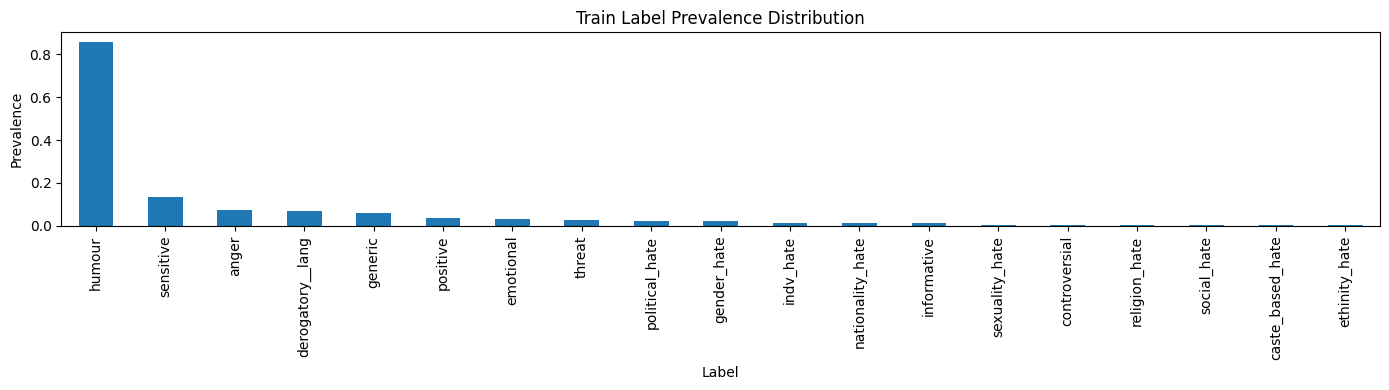

In [22]:
def score_split(y_full, y_train, y_val):
    full_prev = y_full.mean(axis=0)
    train_prev = y_train.mean(axis=0)
    val_prev = y_val.mean(axis=0)
    drift = np.abs(train_prev - full_prev).mean() + np.abs(val_prev - full_prev).mean()
    missing_train = int((y_train.sum(axis=0) == 0).sum())
    missing_val = int(((y_full.sum(axis=0) >= 2) & (y_val.sum(axis=0) == 0)).sum())
    return drift + missing_train * 1.0 + missing_val * 0.5


def multilabel_train_val_split(frame_df, label_cols, val_size=0.2, seed=42, tries=200):
    y = frame_df[label_cols].values
    all_indices = np.arange(len(frame_df))

    try:
        from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

        splitter = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=val_size,
            random_state=seed,
        )
        train_idx, val_idx = next(splitter.split(np.zeros(len(frame_df)), y))
        method = "iterstrat"
    except Exception:
        rng = np.random.default_rng(seed)
        best_pair = None
        best_score = float("inf")

        for _ in range(tries):
            random_state = int(rng.integers(0, 1_000_000_000))
            train_idx, val_idx = train_test_split(
                all_indices,
                test_size=val_size,
                random_state=random_state,
                shuffle=True,
            )
            current_score = score_split(y, y[train_idx], y[val_idx])
            if current_score < best_score:
                best_score = current_score
                best_pair = (train_idx, val_idx)

        train_idx, val_idx = best_pair
        method = f"best-of-{tries} random splits"

    train_df = frame_df.iloc[train_idx].reset_index(drop=True)
    val_df = frame_df.iloc[val_idx].reset_index(drop=True)
    return train_df, val_df, method


# Main split: train vs validation
train_base_df, val_all_df, split_method = multilabel_train_val_split(
    original_df,
    label_columns,
    val_size=CFG["val_size"],
    seed=CFG["seed"],
)

train_source_ids = set(train_base_df["source_video_id"].tolist())
val_source_ids = set(val_all_df["source_video_id"].tolist())

train_df = manifest_df[manifest_df["source_video_id"].isin(train_source_ids)].copy().reset_index(drop=True)
val_all_df = original_df[original_df["source_video_id"].isin(val_source_ids)].copy().reset_index(drop=True)

# Validation split: threshold tuning vs checkpoint/eval (prevents threshold leakage)
val_tune_df, val_eval_df, val_split_method = multilabel_train_val_split(
    val_all_df,
    label_columns,
    val_size=CFG["val_tune_size_within_val"],
    seed=CFG["seed"] + 1,
)

distribution_df = pd.DataFrame(
    {
        "train_original": train_base_df[label_columns].sum().astype(int),
        "train_with_aug": train_df[label_columns].sum().astype(int),
        "val_all": val_all_df[label_columns].sum().astype(int),
        "val_tune": val_tune_df[label_columns].sum().astype(int),
        "val_eval": val_eval_df[label_columns].sum().astype(int),
    }
).sort_values("train_original", ascending=False)

train_prev = train_base_df[label_columns].mean()
val_prev = val_eval_df[label_columns].mean()
train_dead = (train_base_df[label_columns].nunique(dropna=False) <= 1)
val_dead = (val_eval_df[label_columns].nunique(dropna=False) <= 1)

label_diagnostics = pd.DataFrame(
    {
        "train_prevalence": train_prev,
        "val_eval_prevalence": val_prev,
        "train_positive_count": train_base_df[label_columns].sum().astype(int),
        "val_eval_positive_count": val_eval_df[label_columns].sum().astype(int),
        "is_rare_train_lt_1pct": train_prev < 0.01,
        "dead_in_train": train_dead.values,
        "dead_in_val_eval": val_dead.values,
    }
).sort_values("train_prevalence", ascending=False)

print("split method (train/val):", split_method)
print("split method (val_tune/val_eval):", val_split_method)
print(f"train original clips: {len(train_base_df):,}")
print(f"train clips with augmentation: {len(train_df):,}")
print(f"val all clips: {len(val_all_df):,}")
print(f"val tune clips: {len(val_tune_df):,}")
print(f"val eval clips: {len(val_eval_df):,}")
print("rare labels (<1% train prevalence):", int((label_diagnostics["is_rare_train_lt_1pct"]).sum()))
print("dead labels in train:", int(label_diagnostics["dead_in_train"].sum()))
print("dead labels in val_eval:", int(label_diagnostics["dead_in_val_eval"].sum()))

display(distribution_df)
display(label_diagnostics)

fig, ax = plt.subplots(figsize=(14, 4))
label_diagnostics["train_prevalence"].sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Train Label Prevalence Distribution")
ax.set_ylabel("Prevalence")
ax.set_xlabel("Label")
plt.tight_layout()
plt.show()


In [23]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def numeric_frame_key(path: Path):
    stem = path.stem
    return (0, int(stem)) if stem.isdigit() else (1, stem)


def list_frame_paths(frame_dir):
    frame_dir = Path(frame_dir)
    frame_paths = [
        path
        for path in frame_dir.iterdir()
        if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
    return sorted(frame_paths, key=numeric_frame_key)


def _uniform_indices(num_items, num_frames):
    if num_items == 1:
        return np.zeros(num_frames, dtype=np.int32)
    indices = np.linspace(0, num_items - 1, num=num_frames)
    return np.clip(np.round(indices).astype(np.int32), 0, num_items - 1)


def _random_segment_indices(num_items, num_frames):
    if num_items == 1:
        return np.zeros(num_frames, dtype=np.int32)

    if num_items <= num_frames:
        base = _uniform_indices(num_items, num_frames)
        jitter = np.random.randint(-1, 2, size=num_frames)
        return np.clip(base + jitter, 0, num_items - 1)

    bins = np.linspace(0, num_items, num_frames + 1)
    sampled = []
    for start, end in zip(bins[:-1], bins[1:]):
        low = int(np.floor(start))
        high = max(low + 1, int(np.ceil(end)))
        sampled.append(np.random.randint(low, min(high, num_items)))
    return np.asarray(sampled, dtype=np.int32)


def sample_frame_paths(frame_dir, num_frames, train=False):
    frame_paths = list_frame_paths(frame_dir)
    if not frame_paths:
        raise FileNotFoundError(f"No frames found in {frame_dir}")

    if train:
        indices = _random_segment_indices(len(frame_paths), num_frames)
    else:
        indices = _uniform_indices(len(frame_paths), num_frames)

    return [frame_paths[index] for index in indices]


class ClipTransform:
    def __init__(self, image_size=224, train=True):
        self.image_size = image_size
        self.train = train

    def __call__(self, images):
        processed = []

        if self.train:
            i, j, h, w = transforms.RandomResizedCrop.get_params(
                images[0],
                scale=(0.70, 1.0),
                ratio=(0.80, 1.20),
            )
            do_flip = random.random() < 0.5
            brightness = 1.0 + random.uniform(-0.25, 0.25)
            contrast = 1.0 + random.uniform(-0.25, 0.25)
            saturation = 1.0 + random.uniform(-0.25, 0.25)
        else:
            resize_size = int(self.image_size * 1.15)

        for image in images:
            if self.train:
                image = TF.resized_crop(
                    image,
                    i,
                    j,
                    h,
                    w,
                    size=[self.image_size, self.image_size],
                    interpolation=InterpolationMode.BILINEAR,
                )
                if do_flip:
                    image = TF.hflip(image)
                image = TF.adjust_brightness(image, brightness)
                image = TF.adjust_contrast(image, contrast)
                image = TF.adjust_saturation(image, saturation)
            else:
                image = TF.resize(
                    image,
                    size=[resize_size, resize_size],
                    interpolation=InterpolationMode.BILINEAR,
                )
                image = TF.center_crop(image, [self.image_size, self.image_size])

            tensor = TF.to_tensor(image)
            tensor = TF.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)
            processed.append(tensor)

        return torch.stack(processed, dim=0)


class MultiLabelVideoDataset(Dataset):
    def __init__(self, frame_df, label_cols, transform, num_frames, train=False):
        self.frame_df = frame_df.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform
        self.num_frames = num_frames
        self.train = train

    def __len__(self):
        return len(self.frame_df)

    def __getitem__(self, idx):
        row = self.frame_df.iloc[idx]
        frame_paths = sample_frame_paths(row["frame_dir"], self.num_frames, train=self.train)

        images = []
        for frame_path in frame_paths:
            with Image.open(frame_path) as image:
                images.append(image.convert("RGB"))

        clip = self.transform(images)
        label_array = row[self.label_cols].to_numpy(dtype=np.float32, copy=True)
        labels = torch.from_numpy(label_array)
        metadata = {
            "video_key": row["video_key"],
            "source_video_id": row["source_video_id"],
            "is_augmented": int(row["is_augmented"]),
        }
        return clip, labels, metadata


def compute_sample_weights(frame_df, label_cols, max_weight=5.0):
    positive_counts = frame_df[label_cols].sum().clip(lower=1)
    inverse_frequency = 1.0 / positive_counts.values.astype(np.float32)
    weights = []

    for row in frame_df[label_cols].itertuples(index=False):
        positive_vector = np.asarray(row, dtype=np.float32)
        if positive_vector.sum() <= 0:
            sample_weight = float(np.mean(inverse_frequency))
        else:
            sample_weight = float((positive_vector * inverse_frequency).sum() / positive_vector.sum())
        weights.append(sample_weight)

    weights = np.asarray(weights, dtype=np.float32)
    weights = weights / max(1e-6, float(weights.mean()))
    weights = np.clip(weights, 0.25, max_weight)
    return torch.as_tensor(weights, dtype=torch.double)


train_transform = ClipTransform(image_size=CFG["image_size"], train=True)
val_transform = ClipTransform(image_size=CFG["image_size"], train=False)

train_dataset = MultiLabelVideoDataset(
    train_df,
    label_columns,
    train_transform,
    CFG["num_frames"],
    train=True,
)
val_tune_dataset = MultiLabelVideoDataset(
    val_tune_df,
    label_columns,
    val_transform,
    CFG["num_frames"],
    train=False,
)
val_eval_dataset = MultiLabelVideoDataset(
    val_eval_df,
    label_columns,
    val_transform,
    CFG["num_frames"],
    train=False,
)

train_weights = compute_sample_weights(train_df, label_columns, max_weight=CFG["sampler_weight_cap"])
train_sampler = None
train_shuffle = True

if CFG.get("use_weighted_sampler", True):
    train_sampler = WeightedRandomSampler(
        weights=train_weights,
        num_samples=len(train_weights),
        replacement=True,
    )
    train_shuffle = False

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    sampler=train_sampler,
    shuffle=train_shuffle,
    num_workers=CFG["num_workers"],
    pin_memory=USE_AMP,
    drop_last=False,
    persistent_workers=CFG["num_workers"] > 0,
)

val_tune_loader = DataLoader(
    val_tune_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=USE_AMP,
    drop_last=False,
    persistent_workers=CFG["num_workers"] > 0,
)

val_eval_loader = DataLoader(
    val_eval_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=USE_AMP,
    drop_last=False,
    persistent_workers=CFG["num_workers"] > 0,
)

weighted_distribution = pd.DataFrame(
    {
        "train_original": train_base_df[label_columns].sum().astype(int),
        "train_with_aug": train_df[label_columns].sum().astype(int),
        "weighted_sampler_mass": np.dot(train_df[label_columns].T.values, train_weights.numpy()).round(2),
    },
    index=label_columns,
).sort_values("weighted_sampler_mass", ascending=False)

display(weighted_distribution)

print("loader sizes:")
print("  train:", len(train_dataset))
print("  val_tune:", len(val_tune_dataset))
print("  val_eval:", len(val_eval_dataset))

sample_clip, sample_targets, sample_meta = train_dataset[0]
print("sample video:", sample_meta)
print("sample clip shape:", tuple(sample_clip.shape))
print(
    "positive labels:",
    [label_columns[index] for index, value in enumerate(sample_targets.tolist()) if value > 0],
)


,train_original,train_with_aug,weighted_sampler_mass
humour,3513,4229,2608.91
sensitive,561,786,887.75
generic,252,331,543.46
political_hate,102,250,481.26
derogatory__lang,281,374,481.07
positive,156,336,465.59
threat,119,272,460.28
informative,48,192,439.51
anger,304,365,423.80
indv_hate,55,220,417.67


loader sizes:
  train: 5369
  val_tune: 512
  val_eval: 512
sample video: {'video_key': '2', 'source_video_id': '2', 'is_augmented': 0}
sample clip shape: (12, 3, 224, 224)
positive labels: ['generic']


In [24]:
def load_efficientnet_v2_s():
    if not hasattr(tv_models, "efficientnet_v2_s"):
        raise AttributeError("efficientnet_v2_s is not available in this torchvision build")

    builder = tv_models.efficientnet_v2_s
    weights_enum = getattr(tv_models, "EfficientNet_V2_S_Weights", None)

    try:
        model = builder(weights=weights_enum.DEFAULT) if weights_enum is not None else builder(pretrained=True)
        pretrained = True
    except Exception as exc:
        print(f"EfficientNetV2-S pretrained weights unavailable: {exc}")
        model = builder(weights=None) if weights_enum is not None else builder(pretrained=False)
        pretrained = False

    feature_dim = model.classifier[1].in_features
    model.classifier = nn.Identity()
    return model, feature_dim, pretrained


def load_resnet50():
    builder = tv_models.resnet50
    weights_enum = getattr(tv_models, "ResNet50_Weights", None)

    try:
        model = builder(weights=weights_enum.DEFAULT) if weights_enum is not None else builder(pretrained=True)
        pretrained = True
    except Exception as exc:
        print(f"ResNet50 pretrained weights unavailable: {exc}")
        model = builder(weights=None) if weights_enum is not None else builder(pretrained=False)
        pretrained = False

    feature_dim = model.fc.in_features
    model.fc = nn.Identity()
    return model, feature_dim, pretrained


def build_backbone(preferred=None):
    candidates = [preferred] if preferred else ["efficientnet_v2_s", "resnet50"]

    for backbone_name in candidates:
        if backbone_name == "efficientnet_v2_s":
            try:
                backbone, feature_dim, pretrained = load_efficientnet_v2_s()
                return backbone_name, backbone, feature_dim, pretrained
            except Exception as exc:
                print(f"Skipping efficientnet_v2_s: {exc}")
        elif backbone_name == "resnet50":
            backbone, feature_dim, pretrained = load_resnet50()
            return backbone_name, backbone, feature_dim, pretrained
        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}")

    raise RuntimeError("Could not build a supported backbone")


class VideoBaseline(nn.Module):
    def __init__(self, num_labels, backbone_name=None):
        super().__init__()
        self.backbone_name, self.backbone, feature_dim, self.pretrained = build_backbone(backbone_name)
        self.temporal_attention = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(0.35),
            nn.Linear(feature_dim, num_labels),
        )

    def forward(self, clips):
        batch_size, num_frames, channels, height, width = clips.shape
        x = clips.view(batch_size * num_frames, channels, height, width)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        attention = torch.softmax(self.temporal_attention(features).squeeze(-1), dim=1)
        pooled = (features * attention.unsqueeze(-1)).sum(dim=1)
        return self.head(pooled)


class VideoModelV2(nn.Module):
    def __init__(
        self,
        num_labels,
        backbone_name=None,
        num_frames=8,
        embed_dim=640,
        temporal_layers=4,
        temporal_heads=8,
        ffn_dim=1536,
        dropout=0.2,
    ):
        super().__init__()
        self.backbone_name, self.backbone, feature_dim, self.pretrained = build_backbone(backbone_name)

        self.num_frames = int(num_frames)
        self.embed_dim = int(embed_dim)

        self.feature_proj = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, self.embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_frames + 1, self.embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embed_dim,
            nhead=temporal_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.temporal_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=temporal_layers,
            norm=nn.LayerNorm(self.embed_dim),
        )

        self.attn_pool = nn.Sequential(
            nn.LayerNorm(self.embed_dim),
            nn.Linear(self.embed_dim, 1),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(self.embed_dim * 2),
            nn.Linear(self.embed_dim * 2, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_labels),
        )

    def _resize_pos_embed(self, length):
        if self.pos_embed.size(1) == length:
            return self.pos_embed

        pos = self.pos_embed.transpose(1, 2)
        pos = F.interpolate(pos, size=length, mode="linear", align_corners=False)
        return pos.transpose(1, 2)

    def forward(self, clips):
        batch_size, num_frames, channels, height, width = clips.shape
        x = clips.view(batch_size * num_frames, channels, height, width)
        features = self.backbone(x)
        features = features.view(batch_size, num_frames, -1)
        features = self.feature_proj(features)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, features], dim=1)

        pos_embed = self._resize_pos_embed(tokens.size(1))
        tokens = tokens + pos_embed
        tokens = self.temporal_encoder(tokens)

        cls_feature = tokens[:, 0]
        frame_tokens = tokens[:, 1:]
        frame_attn = torch.softmax(self.attn_pool(frame_tokens).squeeze(-1), dim=1)
        pooled_feature = (frame_tokens * frame_attn.unsqueeze(-1)).sum(dim=1)

        combined = torch.cat([cls_feature, pooled_feature], dim=-1)
        return self.head(combined)


MODEL_REGISTRY = {
    "video_baseline": VideoBaseline,
    "video_transformer_v2": VideoModelV2,
}


def build_model(model_type, num_labels, **model_kwargs):
    model_cls = MODEL_REGISTRY.get(model_type)
    if model_cls is None:
        raise ValueError(f"Unsupported model_type: {model_type}")
    return model_cls(num_labels, **model_kwargs)


def freeze_backbone_batchnorm(model):
    for module in model.backbone.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()
            for parameter in module.parameters():
                parameter.requires_grad = False


def set_backbone_trainable(model, trainable):
    for parameter in model.backbone.parameters():
        parameter.requires_grad = trainable
    freeze_backbone_batchnorm(model)


def build_pos_weight(frame_df, label_cols, max_pos_weight):
    positives = frame_df[label_cols].sum().clip(lower=1)
    negatives = len(frame_df) - positives
    weights = (negatives / positives).clip(lower=1.0, upper=max_pos_weight)
    return torch.tensor(weights.values, dtype=torch.float32)


MODEL_KWARGS = {
    "backbone_name": CFG["backbone"],
    "num_frames": CFG["num_frames"],
    "embed_dim": CFG["embed_dim"],
    "temporal_layers": CFG["temporal_layers"],
    "temporal_heads": CFG["temporal_heads"],
    "ffn_dim": CFG["ffn_dim"],
    "dropout": CFG["dropout"],
}

model = build_model(MODEL_TYPE, len(label_columns), **MODEL_KWARGS).to(DEVICE)
set_backbone_trainable(model, False)

# Keep training objective simple and controllable: BCE + pos_weight only.
pos_weight = build_pos_weight(train_df, label_columns, CFG["max_pos_weight"]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scaler = GradScaler(enabled=USE_AMP)

print("model type:", MODEL_TYPE)
print("backbone:", model.backbone_name, "| pretrained:", model.pretrained)
print(
    "trainable parameters:",
    f"{sum(param.numel() for param in model.parameters() if param.requires_grad):,}",
)
print("loss:", criterion.__class__.__name__, "(pos_weight enabled)")
display(
    pd.Series(pos_weight.detach().cpu().numpy(), index=label_columns).sort_values(ascending=False)
)


model type: video_transformer_v2
backbone: efficientnet_v2_s | pretrained: True
trainable parameters: 15,949,844
loss: BCEWithLogitsLoss (pos_weight enabled)


C:\Users\Rasheek\AppData\Local\Temp\ipykernel_26864\335457018.py:223: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


political_hate      20.000000
ethinity_hate       20.000000
indv_hate           20.000000
controversial       20.000000
social_hate         20.000000
sexuality_hate      20.000000
nationality_hate    20.000000
caste_based_hate    20.000000
religion_hate       20.000000
informative         20.000000
threat              18.738970
emotional           18.594891
gender_hate         18.452898
generic             15.220544
positive            14.979167
anger               13.709589
derogatory__lang    13.355615
sensitive            5.830789
humour               1.000000
dtype: float32

In [25]:
# ---- EMA ----
from copy import deepcopy


def create_ema_model(model):
    ema_model = deepcopy(model).eval()
    for parameter in ema_model.parameters():
        parameter.requires_grad_(False)
    return ema_model


def update_ema(model, ema_model, decay):
    with torch.no_grad():
        model_state = model.state_dict()
        ema_state = ema_model.state_dict()

        for key, ema_value in ema_state.items():
            model_value = model_state[key].detach()
            if not torch.is_floating_point(ema_value):
                ema_value.copy_(model_value)
            else:
                ema_value.mul_(decay).add_(model_value, alpha=1.0 - decay)


In [26]:
def build_optimizer(model, backbone_lr, head_lr):
    backbone_named = []
    other_named = []

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if name.startswith("backbone."):
            backbone_named.append((name, parameter))
        else:
            other_named.append((name, parameter))

    def split_decay(named_params):
        decay = []
        no_decay = []
        for name, parameter in named_params:
            if parameter.ndim <= 1 or name.endswith(".bias") or "norm" in name.lower():
                no_decay.append(parameter)
            else:
                decay.append(parameter)
        return decay, no_decay

    param_groups = []
    for named_params, lr in ((backbone_named, backbone_lr), (other_named, head_lr)):
        if not named_params:
            continue
        decay, no_decay = split_decay(named_params)
        if decay:
            param_groups.append({"params": decay, "lr": lr, "weight_decay": CFG["weight_decay"]})
        if no_decay:
            param_groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})

    if not param_groups:
        raise RuntimeError("No trainable parameters found for optimizer")

    optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.999))
    return optimizer


def build_scheduler(optimizer, total_steps, warmup_steps, min_lr_ratio=0.1):
    total_steps = max(1, int(total_steps))
    warmup_steps = max(0, int(warmup_steps))

    def lr_lambda(step):
        if warmup_steps > 0 and step < warmup_steps:
            return max(1e-6, float(step + 1) / float(warmup_steps))

        progress = 0.0
        if total_steps > warmup_steps:
            progress = float(step - warmup_steps) / float(total_steps - warmup_steps)
        progress = min(max(progress, 0.0), 1.0)

        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def optimize_thresholds(y_true, y_prob, metric="f1", default=0.5):
    grid = np.linspace(
        float(CFG.get("threshold_min", 0.10)),
        float(CFG.get("threshold_max", 0.90)),
        int(CFG.get("threshold_steps", 33)),
    )
    thresholds = []

    for label_index in range(y_true.shape[1]):
        y_label = y_true[:, label_index]
        best_threshold = float(default)
        best_score = -1.0

        for threshold in grid:
            preds = (y_prob[:, label_index] >= threshold).astype(np.int32)
            if metric == "label_acc":
                score = float((preds == y_label).mean())
            else:
                if len(np.unique(y_label)) < 2:
                    score = float((preds == y_label).mean())
                else:
                    score = float(f1_score(y_label, preds, zero_division=0))

            if score > best_score:
                best_score = score
                best_threshold = float(threshold)

        thresholds.append(best_threshold)

    return np.asarray(thresholds, dtype=np.float32)


def _per_label_ranking_scores(y_true, y_prob):
    ap_scores = []
    auc_scores = []

    for label_index in range(y_true.shape[1]):
        y_label = y_true[:, label_index]
        p_label = y_prob[:, label_index]

        if len(np.unique(y_label)) < 2:
            ap_scores.append(np.nan)
            auc_scores.append(np.nan)
            continue

        ap_scores.append(float(average_precision_score(y_label, p_label)))
        auc_scores.append(float(roc_auc_score(y_label, p_label)))

    return np.asarray(ap_scores, dtype=np.float32), np.asarray(auc_scores, dtype=np.float32)


def compute_metrics(y_true, y_prob, thresholds):
    thresholds = np.asarray(thresholds, dtype=np.float32)
    if not np.isfinite(y_prob).all():
        sample_index, label_index = np.argwhere(~np.isfinite(y_prob))[0]
        label_name = label_columns[label_index] if "label_columns" in globals() else label_index
        raise ValueError(
            f"y_prob contains non-finite values at sample {sample_index}, label {label_name}"
        )

    preds = (y_prob >= thresholds.reshape(1, -1)).astype(np.int32)

    per_label_f1 = f1_score(y_true, preds, average=None, zero_division=0)
    macro_f1 = f1_score(y_true, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, preds, average="micro", zero_division=0)
    hamming_acc = float((preds == y_true).mean())
    subset_acc = float((preds == y_true).all(axis=1).mean())

    per_label_ap, per_label_auc = _per_label_ranking_scores(y_true, y_prob)
    macro_ap = float(np.nanmean(per_label_ap)) if not np.isnan(per_label_ap).all() else float("nan")
    macro_auc = float(np.nanmean(per_label_auc)) if not np.isnan(per_label_auc).all() else float("nan")

    return {
        "macro_f1": float(macro_f1),
        "micro_f1": float(micro_f1),
        "macro_ap": macro_ap,
        "macro_auc": macro_auc,
        "hamming_acc": hamming_acc,
        "subset_acc": subset_acc,
        "label_acc": hamming_acc,
        "exact_match_acc": subset_acc,
        "per_label_f1": per_label_f1,
        "per_label_ap": per_label_ap,
        "per_label_auc": per_label_auc,
        "preds": preds,
    }


def summarize_prediction_distribution(y_prob, thresholds):
    preds = (y_prob >= thresholds.reshape(1, -1)).astype(np.int32)
    return pd.DataFrame(
        {
            "label": label_columns,
            "mean_prob": y_prob.mean(axis=0),
            "pred_positive_rate": preds.mean(axis=0),
        }
    ).sort_values("pred_positive_rate")


def compute_baseline_suite(y_true, prior_probs, seed=42):
    rng = np.random.default_rng(seed)
    thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)

    zero_prob = np.zeros_like(y_true, dtype=np.float32)
    random_prob = rng.uniform(0.0, 1.0, size=y_true.shape).astype(np.float32)
    prior_prob = np.tile(prior_probs.reshape(1, -1), (y_true.shape[0], 1)).astype(np.float32)

    rows = []
    for name, probs in [
        ("all_zero", zero_prob),
        ("random_uniform", random_prob),
        ("prior_prob", prior_prob),
    ]:
        m = compute_metrics(y_true, probs, thresholds)
        rows.append(
            {
                "baseline": name,
                "macro_f1": m["macro_f1"],
                "macro_ap": m["macro_ap"],
                "macro_auc": m["macro_auc"],
                "micro_f1": m["micro_f1"],
                "label_acc": m["label_acc"],
            }
        )
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False)


def extract_video_ids(metadata):
    if isinstance(metadata, dict):
        source_ids = metadata.get("source_video_id")
        if source_ids is not None:
            return list(source_ids)
        video_keys = metadata.get("video_key")
        if video_keys is not None:
            return list(video_keys)
    return None


def ensure_finite_tensor(name, tensor, metadata=None):
    if torch.isfinite(tensor).all():
        return

    if tensor.ndim == 0:
        message = f"{name} became non-finite"
    else:
        bad_index = tuple(torch.nonzero(~torch.isfinite(tensor), as_tuple=False)[0].tolist())
        message = f"{name} contains non-finite values at index {bad_index}"
        video_ids = extract_video_ids(metadata)
        if video_ids is not None and len(video_ids) > 0:
            sample_index = min(bad_index[0], len(video_ids) - 1)
            message += f" | sample={video_ids[sample_index]}"

    raise RuntimeError(message)


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    scheduler=None,
    accum_steps=1,
    ema_model=None,
    ema_decay=0.999,
):
    is_train = optimizer is not None
    model.train(is_train)
    if is_train and hasattr(model, "backbone"):
        freeze_backbone_batchnorm(model)

    total_loss = 0.0
    all_probs = []
    all_targets = []
    all_video_ids = []

    logit_count = 0
    logit_sum = 0.0
    logit_sq_sum = 0.0
    logit_min = float("inf")
    logit_max = float("-inf")

    progress = tqdm(loader, leave=False)
    progress.set_description("train" if is_train else "val")

    grad_context = torch.enable_grad() if is_train else torch.no_grad()
    amp_enabled = bool(scaler is not None and scaler.is_enabled())
    accum_steps = max(1, int(accum_steps))

    if is_train:
        optimizer.zero_grad(set_to_none=True)

    with grad_context:
        for step, (clips, labels, metadata) in enumerate(progress, start=1):
            clips = clips.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.autocast(device_type=DEVICE.type, enabled=amp_enabled):
                logits = model(clips)
                loss = criterion(logits, labels)

            ensure_finite_tensor("logits", logits, metadata)
            ensure_finite_tensor("loss", loss, metadata)

            if is_train:
                loss_for_step = loss / accum_steps
                scaler.scale(loss_for_step).backward()

                should_step = (step % accum_steps == 0) or (step == len(loader))
                if should_step:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

                    if scheduler is not None:
                        scheduler.step()
                    if ema_model is not None:
                        update_ema(model, ema_model, ema_decay)

            probs = torch.sigmoid(logits)
            ensure_finite_tensor("probabilities", probs, metadata)

            logits_detached = logits.detach()
            logit_count += int(logits_detached.numel())
            logit_sum += float(logits_detached.sum().item())
            logit_sq_sum += float((logits_detached ** 2).sum().item())
            logit_min = min(logit_min, float(logits_detached.min().item()))
            logit_max = max(logit_max, float(logits_detached.max().item()))

            video_ids = extract_video_ids(metadata)
            if video_ids is not None:
                all_video_ids.extend(video_ids)

            total_loss += loss.item() * clips.size(0)
            all_probs.append(probs.detach().cpu())
            all_targets.append(labels.detach().cpu())
            progress.set_postfix(loss=f"{loss.item():.4f}")

    y_prob = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_targets).numpy().astype(np.int32)
    avg_loss = total_loss / max(1, len(loader.dataset))

    logit_mean = logit_sum / max(1, logit_count)
    logit_var = max(0.0, (logit_sq_sum / max(1, logit_count)) - (logit_mean ** 2))
    diagnostics = {
        "prob_mean": float(y_prob.mean()),
        "prob_std": float(y_prob.std()),
        "prob_lt_001": float((y_prob < 0.01).mean()),
        "prob_gt_099": float((y_prob > 0.99).mean()),
        "pred_pos_rate_at_05": float((y_prob >= 0.5).mean()),
        "logit_mean": float(logit_mean),
        "logit_std": float(np.sqrt(logit_var)),
        "logit_min": float(logit_min),
        "logit_max": float(logit_max),
        "source_video_ids": all_video_ids,
    }
    return avg_loss, y_true, y_prob, diagnostics


def save_checkpoint(
    path,
    model,
    ema_model,
    thresholds,
    history,
    epoch,
    best_macro_f1,
    best_macro_ap,
    model_type,
    model_kwargs,
):
    checkpoint = {
        "schema_version": 3,
        "model_type": model_type,
        "model_kwargs": model_kwargs,
        "model_state_dict": model.state_dict(),
        "ema_state_dict": ema_model.state_dict() if ema_model is not None else None,
        "label_columns": label_columns,
        "config": CFG,
        "thresholds": np.asarray(thresholds, dtype=np.float32),
        "threshold_source_split": "val_tune",
        "history": history,
        "epoch": int(epoch),
        "best_macro_f1": float(best_macro_f1),
        "best_macro_ap": float(best_macro_ap),
        "backbone": getattr(model, "backbone_name", None),
    }
    save_path = Path(path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, save_path)


In [27]:
optimizer = build_optimizer(model, CFG["backbone_lr"], CFG["head_lr"])
steps_per_epoch = max(1, int(np.ceil(len(train_loader) / max(1, CFG["accum_steps"]))))
initial_phase_epochs = max(1, CFG["freeze_epochs"])
initial_total_steps = steps_per_epoch * initial_phase_epochs
initial_warmup_steps = max(1, int(initial_total_steps * CFG["warmup_ratio"]))
scheduler = build_scheduler(optimizer, initial_total_steps, initial_warmup_steps)

ema_model = create_ema_model(model)

best_macro_f1 = -1.0
best_macro_ap = -1.0
best_thresholds = np.full(len(label_columns), 0.5, dtype=np.float32)
best_val_eval_y = None
best_val_eval_prob = None
best_val_tune_y = None
best_val_tune_prob = None
history = []
epochs_without_improvement = 0

val_eval_ground_truth = val_eval_df[label_columns].to_numpy(dtype=np.int32)
prior_probs = train_base_df[label_columns].mean().to_numpy(dtype=np.float32)
baseline_df = compute_baseline_suite(val_eval_ground_truth, prior_probs, seed=CFG["seed"])
print("sanity baselines on val_eval:")
display(baseline_df)

for epoch in range(1, CFG["epochs"] + 1):
    if CFG["freeze_epochs"] > 0 and epoch == CFG["freeze_epochs"] + 1:
        set_backbone_trainable(model, True)
        optimizer = build_optimizer(model, CFG["backbone_lr"], CFG["head_lr"])

        remaining_epochs = CFG["epochs"] - epoch + 1
        remaining_total_steps = steps_per_epoch * max(1, remaining_epochs)
        remaining_warmup = max(1, int(remaining_total_steps * CFG["warmup_ratio"]))
        scheduler = build_scheduler(optimizer, remaining_total_steps, remaining_warmup)
        print(f"epoch {epoch:02d}: backbone unfrozen")

    train_loss, train_y, train_prob, train_diag = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        scaler=scaler,
        scheduler=scheduler,
        accum_steps=CFG["accum_steps"],
        ema_model=ema_model,
        ema_decay=CFG["ema_decay"],
    )

    eval_model = ema_model if ema_model is not None else model
    val_tune_loss, val_tune_y, val_tune_prob, val_tune_diag = run_epoch(
        eval_model,
        val_tune_loader,
        criterion,
    )
    val_eval_loss, val_eval_y, val_eval_prob, val_eval_diag = run_epoch(
        eval_model,
        val_eval_loader,
        criterion,
    )

    thresholds = optimize_thresholds(
        val_tune_y,
        val_tune_prob,
        metric=CFG["threshold_metric"],
        default=0.5,
    )
    default_thresholds = np.full(len(label_columns), 0.5, dtype=np.float32)

    train_metrics = compute_metrics(train_y, train_prob, thresholds)
    val_eval_metrics = compute_metrics(val_eval_y, val_eval_prob, thresholds)
    val_eval_default_metrics = compute_metrics(val_eval_y, val_eval_prob, default_thresholds)
    val_tune_metrics = compute_metrics(val_tune_y, val_tune_prob, thresholds)

    pred_distribution = summarize_prediction_distribution(val_eval_prob, thresholds)
    collapsed_labels = pred_distribution.head(3)["label"].tolist()

    current_lrs = [group["lr"] for group in optimizer.param_groups]
    epoch_row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_tune_loss": val_tune_loss,
        "val_eval_loss": val_eval_loss,
        "train_macro_f1": train_metrics["macro_f1"],
        "val_tune_macro_f1": val_tune_metrics["macro_f1"],
        "val_eval_macro_f1": val_eval_metrics["macro_f1"],
        "val_eval_macro_ap": val_eval_metrics["macro_ap"],
        "val_eval_macro_auc": val_eval_metrics["macro_auc"],
        "val_eval_micro_f1": val_eval_metrics["micro_f1"],
        "val_eval_macro_f1_at_05": val_eval_default_metrics["macro_f1"],
        "val_eval_label_acc_debug": val_eval_metrics["label_acc"],
        "val_eval_exact_acc_debug": val_eval_metrics["exact_match_acc"],
        "train_prob_mean": train_diag["prob_mean"],
        "val_eval_prob_mean": val_eval_diag["prob_mean"],
        "val_eval_pred_pos_at_05": val_eval_diag["pred_pos_rate_at_05"],
        "lr_min": float(np.min(current_lrs)),
        "lr_max": float(np.max(current_lrs)),
    }
    history.append(epoch_row)

    print(
        f"epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | val_eval_loss={val_eval_loss:.4f} | "
        f"val_macro_f1={val_eval_metrics['macro_f1']:.4f} | "
        f"val_macro_ap={val_eval_metrics['macro_ap']:.4f} | "
        f"val_macro_auc={val_eval_metrics['macro_auc']:.4f} | "
        f"val_micro_f1={val_eval_metrics['micro_f1']:.4f} | "
        f"val_label_acc(debug)={val_eval_metrics['label_acc']:.4f} | "
        f"lr=[{np.min(current_lrs):.2e}, {np.max(current_lrs):.2e}]"
    )
    print(
        f"  calibration | logit_mean={val_eval_diag['logit_mean']:.3f} "
        f"logit_std={val_eval_diag['logit_std']:.3f} "
        f"prob_mean={val_eval_diag['prob_mean']:.3f} "
        f"prob<0.01={val_eval_diag['prob_lt_001']:.3f} "
        f"prob>0.99={val_eval_diag['prob_gt_099']:.3f}"
    )
    print(f"  collapsed-label check | lowest predicted-positive labels: {collapsed_labels}")

    save_checkpoint(
        LAST_CHECKPOINT_PATH,
        model,
        ema_model,
        thresholds,
        history,
        epoch,
        best_macro_f1,
        best_macro_ap,
        MODEL_TYPE,
        MODEL_KWARGS,
    )

    improved = False
    if val_eval_metrics["macro_f1"] > best_macro_f1 + 1e-6:
        improved = True
    elif abs(val_eval_metrics["macro_f1"] - best_macro_f1) <= 1e-6 and val_eval_metrics["macro_ap"] > best_macro_ap + 1e-6:
        improved = True

    if improved:
        best_macro_f1 = float(val_eval_metrics["macro_f1"])
        best_macro_ap = float(val_eval_metrics["macro_ap"])
        best_thresholds = thresholds.copy()
        best_val_eval_y = val_eval_y.copy()
        best_val_eval_prob = val_eval_prob.copy()
        best_val_tune_y = val_tune_y.copy()
        best_val_tune_prob = val_tune_prob.copy()
        epochs_without_improvement = 0

        save_checkpoint(
            CHECKPOINT_PATH,
            model,
            ema_model,
            best_thresholds,
            history,
            epoch,
            best_macro_f1,
            best_macro_ap,
            MODEL_TYPE,
            MODEL_KWARGS,
        )
        save_checkpoint(
            CHECKPOINT_PATH_EMA,
            model,
            ema_model,
            best_thresholds,
            history,
            epoch,
            best_macro_f1,
            best_macro_ap,
            MODEL_TYPE,
            MODEL_KWARGS,
        )
        print(f"saved best checkpoint -> {CHECKPOINT_PATH.name}")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CFG["patience"]:
            print("early stopping triggered")
            break

history_df = pd.DataFrame(history)
display(history_df)

if best_val_eval_y is None or best_val_eval_prob is None:
    raise RuntimeError("No best checkpoint selected during training.")

best_eval_metrics = compute_metrics(best_val_eval_y, best_val_eval_prob, best_thresholds)
best_distribution = summarize_prediction_distribution(best_val_eval_prob, best_thresholds)

per_label_df = pd.DataFrame(
    {
        "label": label_columns,
        "threshold": best_thresholds,
        "val_eval_f1": best_eval_metrics["per_label_f1"],
        "val_eval_ap": best_eval_metrics["per_label_ap"],
        "val_eval_auc": best_eval_metrics["per_label_auc"],
        "val_eval_mean_prob": best_distribution.set_index("label")["mean_prob"].reindex(label_columns).values,
        "val_eval_pred_positive_rate": best_distribution.set_index("label")["pred_positive_rate"].reindex(label_columns).values,
        "train_prevalence": train_base_df[label_columns].mean().values,
        "val_tune_prevalence": val_tune_df[label_columns].mean().values,
        "val_eval_prevalence": val_eval_df[label_columns].mean().values,
        "is_rare_train_lt_1pct": (train_base_df[label_columns].mean().values < 0.01),
        "dead_train": (train_base_df[label_columns].nunique(dropna=False).values <= 1),
        "dead_val_eval": (val_eval_df[label_columns].nunique(dropna=False).values <= 1),
    }
).sort_values("val_eval_f1", ascending=False)

display(per_label_df)


def build_prediction_audit_table(frame_df, y_true, y_prob, thresholds, label_cols, n_samples=8, seed=42):
    rng = np.random.default_rng(seed)
    n = len(frame_df)
    count = min(n_samples, n)
    indices = rng.choice(np.arange(n), size=count, replace=False)
    rows = []

    preds = (y_prob >= thresholds.reshape(1, -1)).astype(np.int32)
    for idx in sorted(indices.tolist()):
        row = frame_df.iloc[idx]
        true_labels = [label_cols[j] for j, v in enumerate(y_true[idx]) if int(v) == 1]
        pred_labels = [label_cols[j] for j, v in enumerate(preds[idx]) if int(v) == 1]

        top_indices = np.argsort(y_prob[idx])[::-1][:5]
        top_probs = ", ".join([f"{label_cols[j]}:{y_prob[idx][j]:.2f}" for j in top_indices])

        rows.append(
            {
                "source_video_id": row["source_video_id"],
                "video_key": row["video_key"],
                "true_labels": ", ".join(true_labels) if true_labels else "<none>",
                "pred_labels": ", ".join(pred_labels) if pred_labels else "<none>",
                "top_probs": top_probs,
            }
        )
    return pd.DataFrame(rows)


audit_df = build_prediction_audit_table(
    val_eval_df.reset_index(drop=True),
    best_val_eval_y,
    best_val_eval_prob,
    best_thresholds,
    label_columns,
    n_samples=8,
    seed=CFG["seed"],
)
display(audit_df)

print("reporting notes:")
print("- Primary metric: macro F1")
print("- Secondary metric: macro AP")
print("- Diagnostic metric: micro F1")
print("- Threshold-free metrics included each epoch: macro AP + macro ROC-AUC")
print("- Thresholds are tuned only on val_tune, and reported on val_eval")
print("- label_acc/subset_acc are debug-only and not used for checkpoint selection")


sanity baselines on val_eval:


,baseline,macro_f1,macro_ap,macro_auc,micro_f1,label_acc
1,random_uniform,0.086609,0.094473,0.564864,0.132350,0.504009
2,prior_prob,0.048710,0.081457,0.500000,0.722359,0.965152
0,all_zero,0.000000,0.081457,0.500000,0.000000,0.927118


epoch 01 | train_loss=1.1239 | val_eval_loss=0.9356 | val_macro_f1=0.0946 | val_macro_ap=0.0974 | val_macro_auc=0.5830 | val_micro_f1=0.2888 | val_label_acc(debug)=0.7089 | lr=[5.00e-05, 5.00e-05]
  calibration | logit_mean=0.048 logit_std=0.229 prob_mean=0.512 prob<0.01=0.000 prob>0.99=0.000
  collapsed-label check | lowest predicted-positive labels: ['positive', 'gender_hate', 'indv_hate']
saved best checkpoint -> best_full_dataset_model.pt
epoch 02: backbone unfrozen


epoch 02 | train_loss=0.8435 | val_eval_loss=0.9127 | val_macro_f1=0.1079 | val_macro_ap=0.1126 | val_macro_auc=0.6505 | val_micro_f1=0.3644 | val_label_acc(debug)=0.8075 | lr=[4.20e-05, 4.20e-04]
  calibration | logit_mean=0.024 logit_std=0.366 prob_mean=0.506 prob<0.01=0.000 prob>0.99=0.000
  collapsed-label check | lowest predicted-positive labels: ['indv_hate', 'threat', 'political_hate']
saved best checkpoint -> best_full_dataset_model.pt


epoch 03 | train_loss=0.8193 | val_eval_loss=0.8801 | val_macro_f1=0.1158 | val_macro_ap=0.1365 | val_macro_auc=0.6812 | val_micro_f1=0.3680 | val_label_acc(debug)=0.8051 | lr=[4.96e-05, 4.96e-04]
  calibration | logit_mean=-0.035 logit_std=0.513 prob_mean=0.493 prob<0.01=0.000 prob>0.99=0.000
  collapsed-label check | lowest predicted-positive labels: ['informative', 'indv_hate', 'threat']
saved best checkpoint -> best_full_dataset_model.pt


...

epoch 16 | train_loss=0.0700 | val_eval_loss=0.8543 | val_macro_f1=0.1813 | val_macro_ap=0.1674 | val_macro_auc=0.7257 | val_micro_f1=0.5173 | val_label_acc(debug)=0.8950 | lr=[5.00e-06, 5.00e-05]
  calibration | logit_mean=-3.381 logit_std=3.356 prob_mean=0.215 prob<0.01=0.433 prob>0.99=0.003
  collapsed-label check | lowest predicted-positive labels: ['informative', 'indv_hate', 'nationality_hate']
saved best checkpoint -> best_full_dataset_model.pt


,epoch,train_loss,val_tune_loss,val_eval_loss,train_macro_f1,val_tune_macro_f1,val_eval_macro_f1,val_eval_macro_ap,val_eval_macro_auc,val_eval_micro_f1,val_eval_macro_f1_at_05,val_eval_label_acc_debug,val_eval_exact_acc_debug,train_prob_mean,val_eval_prob_mean,val_eval_pred_pos_at_05,lr_min,lr_max
0,1,1.123931,0.939559,0.935598,0.299703,0.135919,0.094636,0.097406,0.583015,0.288800,0.103167,0.708882,0.000000,0.445312,0.511815,0.598479,0.000050,0.000050
1,2,0.843495,0.917261,0.912654,0.458377,0.157678,0.107871,0.112570,0.650475,0.364438,0.109445,0.807463,0.025391,0.340088,0.506135,0.563528,0.000042,0.000420
2,3,0.819294,0.885215,0.880060,0.482414,0.194911,0.115837,0.136468,0.681204,0.368000,0.112556,0.805099,0.015625,0.315674,0.492577,0.527035,0.000050,0.000496
3,4,0.607003,0.854106,0.849068,0.600051,0.223622,0.125659,0.136462,0.694384,0.372906,0.116154,0.819182,0.017578,0.256104,0.475539,0.482319,0.000048,0.000481
4,5,0.498095,0.826634,0.821769,0.666801,0.227870,0.125351,0.143718,0.698563,0.356283,0.117134,0.802015,0.011719,0.229004,0.456728,0.439145,0.000046,0.000456
5,6,0.405262,0.799326,0.793892,0.707786,0.222471,0.131766,0.147113,0.704511,0.334606,0.124476,0.784951,0.005859,0.198242,0.433213,0.402755,0.000042,0.000421
6,7,0.341660,0.772131,0.765982,0.762772,0.234426,0.138365,0.151418,0.712596,0.342020,0.127525,0.792352,0.005859,0.183838,0.406851,0.375103,0.000038,0.000378
7,8,0.280375,0.750709,0.743112,0.801988,0.230384,0.160814,0.153409,0.716922,0.354860,0.134378,0.796669,0.003906,0.166870,0.380037,0.350535,0.000033,0.000331
8,9,0.216552,0.734821,0.724929,0.841306,0.236366,0.151237,0.158020,0.720688,0.379792,0.135615,0.822060,0.017578,0.153320,0.352845,0.330078,0.000028,0.000280
9,10,0.186656,0.727347,0.714410,0.865370,0.225945,0.135365,0.159719,0.724016,0.417821,0.140301,0.840152,0.037109,0.143555,0.327004,0.311678,0.000023,0.000229


,label,threshold,val_eval_f1,val_eval_ap,val_eval_auc,val_eval_mean_prob,val_eval_pred_positive_rate,train_prevalence,val_tune_prevalence,val_eval_prevalence,is_rare_train_lt_1pct,dead_train,dead_val_eval
1,humour,0.100,0.923239,0.884780,0.590591,0.754771,0.996094,0.858085,0.863281,0.861328,False,False,False
11,informative,0.900,0.600000,0.520528,0.872530,0.035092,0.007812,0.011724,0.007812,0.011719,False,False,False
18,gender_hate,0.750,0.250000,0.128424,0.822112,0.101117,0.042969,0.022228,0.015625,0.019531,False,False,False
3,sensitive,0.400,0.237762,0.135651,0.515633,0.482838,0.705078,0.137030,0.138672,0.132812,False,False,False
14,emotional,0.900,0.230769,0.212618,0.719192,0.358870,0.068359,0.032731,0.025391,0.033203,False,False,False
13,anger,0.850,0.204082,0.127087,0.663432,0.595903,0.218750,0.074255,0.066406,0.068359,False,False,False
4,derogatory__lang,0.875,0.188235,0.115885,0.633200,0.470995,0.101562,0.068637,0.072266,0.064453,False,False,False
0,generic,0.900,0.171429,0.159967,0.623720,0.442910,0.068359,0.061553,0.060547,0.068359,False,False,False
17,indv_hate,0.825,0.166667,0.134141,0.794342,0.053664,0.009766,0.013434,0.011719,0.013672,False,False,False
9,political_hate,0.900,0.166667,0.101903,0.792667,0.141349,0.046875,0.024915,0.033203,0.023438,False,False,False


,source_video_id,video_key,true_labels,pred_labels,top_probs
0,4241,4241,"humour, political_hate","humour, caste_based_hate, emotional","emotional:0.94, anger:0.82, humour:0.76, polit..."
1,585,585,humour,"humour, sensitive","humour:0.78, derogatory__lang:0.76, anger:0.74..."
2,3611,3611,"generic, humour","humour, sensitive","anger:0.80, humour:0.77, derogatory__lang:0.72..."
3,4958,4958,"humour, emotional","humour, political_hate","political_hate:0.95, humour:0.93, derogatory__..."
4,2403,2403,humour,"humour, sensitive, derogatory__lang, sexuality...","derogatory__lang:0.90, humour:0.79, sensitive:..."
5,5001,5001,generic,"humour, positive, sensitive, emotional","emotional:0.94, humour:0.76, positive:0.72, se..."
6,4353,4353,humour,"humour, positive, sensitive","generic:0.88, humour:0.66, sensitive:0.51, ang..."
7,993,993,generic,"humour, sensitive, anger","anger:0.90, generic:0.82, derogatory__lang:0.7..."


reporting notes:
- Primary metric: macro F1
- Secondary metric: macro AP
- Diagnostic metric: micro F1
- Threshold-free metrics included each epoch: macro AP + macro ROC-AUC
- Thresholds are tuned only on val_tune, and reported on val_eval
- label_acc/subset_acc are debug-only and not used for checkpoint selection


In [28]:
def infer_model_kwargs_from_state_dict(state_dict, checkpoint):
    kwargs = {}
    cls_token = state_dict.get("cls_token")
    if cls_token is not None and cls_token.ndim == 3:
        kwargs["embed_dim"] = int(cls_token.shape[-1])

    pos_embed = state_dict.get("pos_embed")
    if pos_embed is not None and pos_embed.ndim == 3:
        kwargs["num_frames"] = int(pos_embed.shape[1] - 1)

    layer_prefix = "temporal_encoder.layers."
    layer_ids = set()
    for key in state_dict:
        if key.startswith(layer_prefix):
            parts = key.split(".")
            if len(parts) > 3 and parts[2].isdigit():
                layer_ids.add(int(parts[2]))
    if layer_ids:
        kwargs["temporal_layers"] = max(layer_ids) + 1

    in_proj = state_dict.get("temporal_encoder.layers.0.self_attn.in_proj_weight")
    if in_proj is not None and in_proj.ndim == 2:
        embed_dim = in_proj.shape[1]
        for candidate in (16, 12, 10, 8, 6, 5, 4, 2, 1):
            if embed_dim % candidate == 0:
                kwargs["temporal_heads"] = candidate
                break

    fc1 = state_dict.get("temporal_encoder.layers.0.linear1.weight")
    if fc1 is not None and fc1.ndim == 2:
        kwargs["ffn_dim"] = int(fc1.shape[0])

    kwargs["backbone_name"] = checkpoint.get("backbone", CFG.get("backbone", "efficientnet_v2_s"))
    kwargs.setdefault("num_frames", checkpoint.get("config", {}).get("num_frames", CFG["num_frames"]))
    kwargs.setdefault("dropout", checkpoint.get("config", {}).get("dropout", CFG["dropout"]))
    return kwargs


def build_model_from_checkpoint(checkpoint):
    num_labels = len(checkpoint["label_columns"])

    model_type = checkpoint.get("model_type")
    model_kwargs = checkpoint.get("model_kwargs") or {}

    if model_type in MODEL_REGISTRY:
        return build_model(model_type, num_labels, **model_kwargs), model_type

    state_dict = checkpoint["model_state_dict"]
    transformer_keys = {"feature_proj.1.weight", "cls_token", "temporal_encoder.layers.0.self_attn.in_proj_weight"}
    if transformer_keys.intersection(state_dict.keys()):
        inferred_kwargs = infer_model_kwargs_from_state_dict(state_dict, checkpoint)
        return build_model("video_transformer_v2", num_labels, **inferred_kwargs), "video_transformer_v2"

    return VideoBaseline(num_labels, backbone_name=checkpoint.get("backbone")), "video_baseline"


def load_checkpoint(checkpoint_path=CHECKPOINT_PATH, device=DEVICE, use_ema=True):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model, resolved_model_type = build_model_from_checkpoint(checkpoint)

    state_key = "ema_state_dict" if use_ema and checkpoint.get("ema_state_dict") is not None else "model_state_dict"
    state_dict = checkpoint[state_key]

    try:
        model.load_state_dict(state_dict, strict=True)
    except RuntimeError:
        model.load_state_dict(state_dict, strict=False)

    model.to(device)
    model.eval()

    checkpoint["resolved_model_type"] = resolved_model_type
    checkpoint["loaded_state_key"] = state_key
    return model, checkpoint


def predict_from_frame_dir(frame_dir, checkpoint_path=CHECKPOINT_PATH, use_ema=True):
    model, checkpoint = load_checkpoint(checkpoint_path=checkpoint_path, use_ema=use_ema)
    frame_dir = Path(frame_dir)

    cfg = checkpoint.get("config", {})
    num_frames = int(cfg.get("num_frames", CFG["num_frames"]))
    image_size = int(cfg.get("image_size", CFG["image_size"]))

    frame_paths = sample_frame_paths(frame_dir, num_frames, train=False)

    images = []
    for frame_path in frame_paths:
        with Image.open(frame_path) as image:
            images.append(image.convert("RGB"))

    inference_transform = ClipTransform(image_size=image_size, train=False)
    clip = inference_transform(images).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.sigmoid(model(clip)).squeeze(0).cpu().numpy()

    thresholds = np.asarray(checkpoint.get("thresholds", np.full(len(checkpoint["label_columns"]), 0.5)), dtype=np.float32)
    preds = (probs >= thresholds).astype(int)

    return pd.DataFrame(
        {
            "label": checkpoint["label_columns"],
            "prob": probs,
            "threshold": thresholds,
            "pred": preds,
        }
    ).sort_values("prob", ascending=False)


# Example usage after training:
# predict_from_frame_dir(FRAMES_ROOT / str(train_base_df.loc[0, "source_video_id"]))
